<a href="https://colab.research.google.com/github/Young-yrx/guizhou-landslide/blob/main/guizhou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XGBoost

In [1]:
# -*- coding: utf-8 -*-
"""
贵州水城滑坡易发性评价 —— XGBoost 二分类模型（含5个降雨因子）
特征列表（共11个）：
    地形因子：Curvatu_ASTG1, Aspect_ASTGT1, Slope_ASTGTM1, Reclass_ASTG1, PTC, TWI
    降雨因子：rain20190716, rain20190720, rain20190721, rain20190722, rain20190723
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
import xgboost as xgb
import rasterio
import warnings
warnings.filterwarnings('ignore')

In [3]:
# -----------------------------------
# 1. 读取数据（假设两个文件的列名已统一）
# -----------------------------------
df_landslide = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/landslide.xls', sheet_name='landslide')
df_non = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/non_landslide.xls', sheet_name='non_landslide')

# 定义11个特征列名（请确保两个文件中的列名完全一致）
feature_cols = [
    'Curvatu_ASTG1',      # 曲率
    'Aspect_ASTGT1',      # 坡向
    'Slope_ASTGTM1',      # 坡度
    'Reclass_ASTG1',      # 重分类（岩性/地层）
    'PTC',                # PTC（剖面曲率或其它）
    'TWI',                # 地形湿度指数
    'rain20190716',       # 降雨量 2019-07-16
    'rain20190720',       # 降雨量 2019-07-20
    'rain20190721',       # 降雨量 2019-07-21
    'rain20190722',       # 降雨量 2019-07-22
    'rain20190723'        # 降雨量 2019-07-23
]

# 提取特征和标签
X_landslide = df_landslide[feature_cols].copy()
y_landslide = np.ones(len(X_landslide))  # 滑坡标签 = 1

X_non = df_non[feature_cols].copy()
y_non = np.zeros(len(X_non))             # 非滑坡标签 = 0

# 合并数据
X = pd.concat([X_landslide, X_non], axis=0, ignore_index=True)
y = np.concatenate([y_landslide, y_non])

print(f"总样本数: {len(X)}，滑坡样本: {int(y.sum())}，非滑坡样本: {len(y) - int(y.sum())}")
print(f"特征列名: {X.columns.tolist()}")


总样本数: 2400，滑坡样本: 1200，非滑坡样本: 1200
特征列名: ['Curvatu_ASTG1', 'Aspect_ASTGT1', 'Slope_ASTGTM1', 'Reclass_ASTG1', 'PTC', 'TWI', 'rain20190716', 'rain20190720', 'rain20190721', 'rain20190722', 'rain20190723']


In [4]:
# -----------------------------------
# 2. 划分训练集与测试集
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)}，测试集: {len(X_test)}")

# -----------------------------------
# 3. 训练 XGBoost 模型
# -----------------------------------
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)


训练集: 1920，测试集: 480


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


测试集准确率: 0.9688
测试集 AUC: 0.9975

分类报告:
               precision    recall  f1-score   support

Non-landslide       1.00      0.94      0.97       240
    Landslide       0.94      1.00      0.97       240

     accuracy                           0.97       480
    macro avg       0.97      0.97      0.97       480
 weighted avg       0.97      0.97      0.97       480



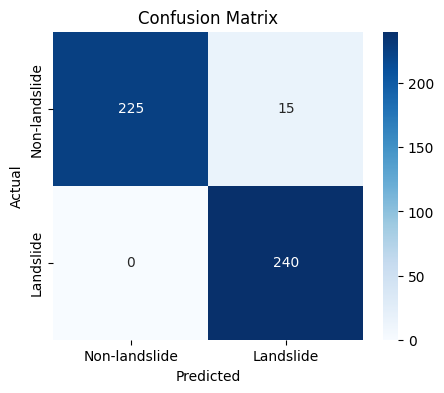

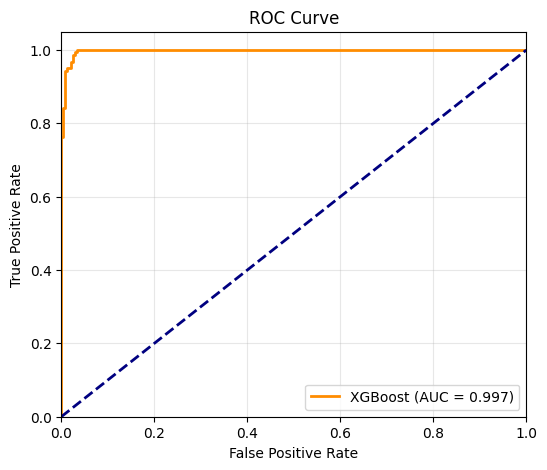

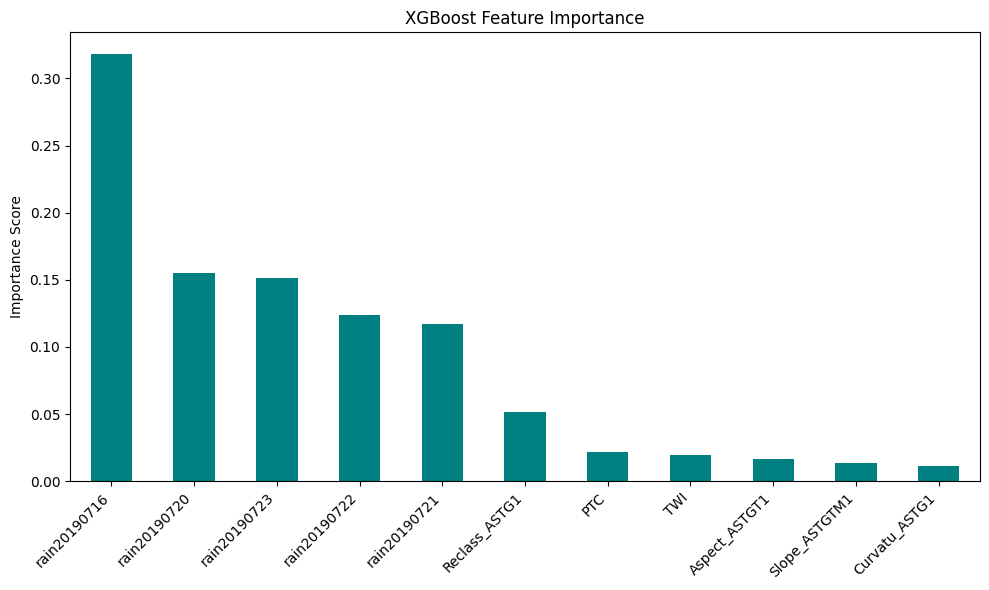

In [5]:
# -----------------------------------
# 4. 模型评估
# -----------------------------------
y_pred = xgb_model.predict(X_test)
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"\n测试集准确率: {acc:.4f}")
print(f"测试集 AUC: {auc_score:.4f}")
print("\n分类报告:")
print(classification_report(y_test, y_pred, target_names=['Non-landslide', 'Landslide']))

# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-landslide', 'Landslide'],
            yticklabels=['Non-landslide', 'Landslide'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 特征重要性
importance = xgb_model.feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='teal')
plt.title('XGBoost Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
# -----------------------------------
# 5. 研究区栅格预测（需准备11个栅格文件）
# -----------------------------------
"""
请确保您已准备好以下11个栅格文件，且它们具有相同的地理范围、像元大小和坐标系。
栅格读取顺序必须与 feature_cols 列表完全一致。

示例文件列表：
raster_files = [
    'curvature.tif',       # 曲率
    'aspect.tif',          # 坡向
    'slope.tif',           # 坡度
    'reclass.tif',         # 重分类
    'ptc.tif',             # PTC
    'twi.tif',             # TWI
    'rain20190716.tif',    # 降雨量 0716
    'rain20190720.tif',    # 降雨量 0720
    'rain20190721.tif',    # 降雨量 0721
    'rain20190722.tif',    # 降雨量 0722
    'rain20190723.tif'     # 降雨量 0723
]
"""

# 请根据实际文件路径修改此列表
raster_files = [
    '/content/drive/MyDrive/Colab Notebooks/date/Curvatu_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Aspect_ASTGT1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Slope_ASTGTM1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Reclass_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/PTC.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/TWI.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190716.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190720.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190721.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190722.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190723.tif'
]

# 检查栅格文件数量
if len(raster_files) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files)}) 与特征数量 ({len(feature_cols)}) 不一致！")

# 打开第一个栅格获取参考元数据
with rasterio.open(raster_files[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)
    transform = src.transform
    crs = src.crs

# 创建特征堆栈
feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files)), dtype=np.float32)

for i, fpath in enumerate(raster_files):
    with rasterio.open(fpath) as src:
        shape = (src.height, src.width)
        if shape != ref_shape:
            raise ValueError(
                f"栅格尺寸不一致！\n"
                f"参考文件: {raster_files[0]} 尺寸: {ref_shape}\n"
                f"当前文件: {fpath} 尺寸: {shape}\n"
                "请确保所有栅格文件具有相同的行列数和地理范围。"
            )
        feature_stack[:, :, i] = src.read(1)

# 处理 NoData 值（假设无效值小于 -9990，根据实际情况调整）
feature_stack[feature_stack < -9990] = np.nan


# 转换为二维表格并剔除含有 NaN 的像素
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

print(f"总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

# 预测滑坡概率
if valid_features.shape[0] > 0:
    pred_prob = xgb_model.predict_proba(valid_features)[:, 1]
else:
    raise ValueError("没有有效像素，请检查栅格数据范围和 NoData 值设置。")

# 生成全图概率图
prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
prob_map[valid_mask] = pred_prob
prob_map = prob_map.reshape(rows, cols)



总像素数: 12967201，有效像素数: 6676231


In [12]:
# 保存 GeoTIFF
output_file = '/content/drive/MyDrive/Colab Notebooks/result/landslide_susceptibility_xgboost_with_rainfall.tif'
profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
with rasterio.open(output_file, 'w', **profile) as dst:
    dst.write(prob_map, 1)

print(f"滑坡易发性图已保存至: {output_file}")


滑坡易发性图已保存至: /content/drive/MyDrive/Colab Notebooks/result/landslide_susceptibility_xgboost_with_rainfall.tif


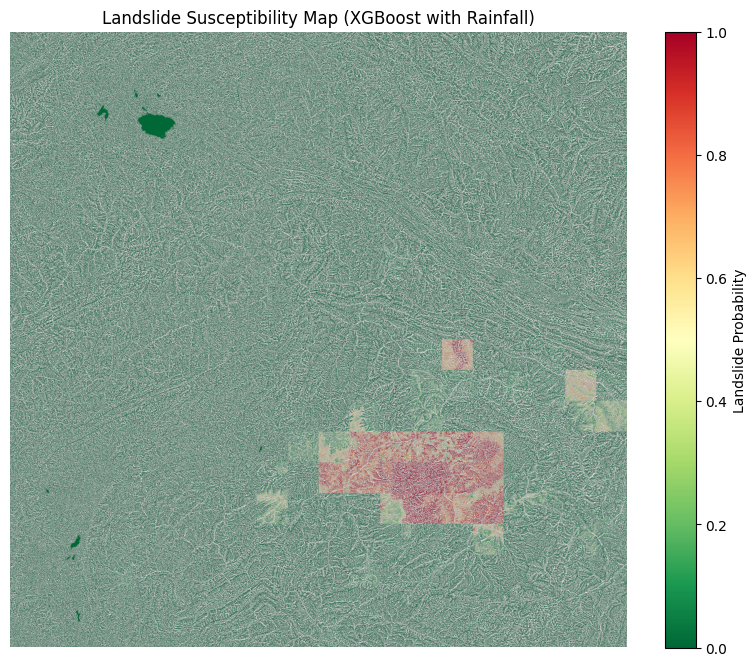

In [13]:
# 预览
plt.figure(figsize=(10, 8))
plt.imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
plt.colorbar(label='Landslide Probability')
plt.title('Landslide Susceptibility Map (XGBoost with Rainfall)')
plt.axis('off')
plt.show()